In [2]:
!pip install -q --upgrade kaggle

import os
from google.colab import userdata

os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
os.environ["KAGGLE_KEY"] = userdata.get("mkk")

print("Kaggle credentials loaded successfully.")

Kaggle credentials loaded successfully.


In [3]:
!mkdir -p /content/data
!kaggle datasets list -s smile

ref                                                      title                                                    size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-------------------------------------------------------  ------------------------------------------------  -----------  --------------------------  -------------  ---------  ---------------  
ashkhagan/smile-twitter-emotion-dataset                  SMILE Twitter Emotion Dataset                          388526  2020-07-13 14:47:15.207000           2531         20  0.9411765        
ghousethanedar/smiledetection                            smile-detection                                      10788287  2020-08-31 10:47:08.573000           1389         22  0.5              
mpwolke/cusersmarilonedriveimagenssmileypng              Smiley                                                  94407  2020-10-25 23:08:29.437000             90         29  1                
art3mis/chembl22                        

In [4]:
!mkdir -p /content/data

!kaggle datasets download talhasar/genki4k  -p /content/data

print("Dataset downloaded.")

Dataset URL: https://www.kaggle.com/datasets/talhasar/genki4k
License(s): CC-BY-NC-SA-4.0
100% 25.0M/25.0M [00:00<00:00, 80.6MB/s]

Dataset downloaded.


In [5]:
import zipfile
import os

zip_path = "/content/data/genki4k.zip"
extract_path = "/content/data/genki4k_extracted"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted to:", extract_path)

Dataset extracted to: /content/data/genki4k_extracted


In [6]:
import os

extracted_dataset_path = "/content/data/genki4k_extracted"

# List contents of the extracted directory
print("Contents of the extracted dataset:")
for root, dirs, files in os.walk(extracted_dataset_path):
    level = root.replace(extracted_dataset_path, '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 4 * (level + 1)
    for f in files:
        print(f'{subindent}{f}')

Contents of the extracted dataset:
genki4k_extracted/
    kaggle-genki4k/
        smile/
            file1879.jpg
            file1963.jpg
            file1782.jpg
            file0018.jpg
            file0597.jpg
            file1018.jpg
            file0050.jpg
            file2140.jpg
            file0758.jpg
            file2135.jpg
            file1878.jpg
            file1248.jpg
            file0197.jpg
            file1176.jpg
            file0377.jpg
            file0194.jpg
            file1683.jpg
            file1568.jpg
            file1965.jpg
            file0588.jpg
            file1065.jpg
            file1287.jpg
            file1236.jpg
            file1257.jpg
            file2025.jpg
            file0750.jpg
            file2048.jpg
            file0117.jpg
            file2107.jpg
            file0713.jpg
            file0938.jpg
            file0914.jpg
            file1473.jpg
            file1342.jpg
            file0211.jpg
            file0091.jpg
           

This will show us the structure of the dataset. Look for a `README.md` file or any CSVs/JSONs that might contain metadata about the dataset.

In [7]:
import os

base_dir = "/content/data/genki4k_extracted/kaggle-genki4k"

print(os.listdir(base_dir))

print(
    "Smile:",
    len(os.listdir(os.path.join(base_dir,"smile")))
)

print(
    "Non-Smile:",
    len(os.listdir(os.path.join(base_dir,"non_smile")))
)

['smile', 'non_smile']
Smile: 2162
Non-Smile: 1838


In [8]:
import os
import tensorflow as tf

dataset_path = "/content/data/genki4k_extracted/kaggle-genki4k"

bad_files = []

for root, _, files in os.walk(dataset_path):
    for file in files:

        path = os.path.join(root,file)

        try:
            img = tf.io.read_file(path)
            tf.io.decode_image(img, channels=3)

        except Exception:
            print("Bad file:", path)
            bad_files.append(path)


print("Total bad files:", len(bad_files))

Total bad files: 0


In [9]:
import os

for file in bad_files:
    os.remove(file)
    print("Deleted:", file)

print("Cleaning completed.")

Cleaning completed.


In [10]:
from tensorflow import keras


train_ds = keras.utils.image_dataset_from_directory(
    "/content/data/genki4k_extracted/kaggle-genki4k",

    validation_split=0.2,
    subset="training",

    seed=42,

    image_size=(150,150),
    batch_size=32)



validation_ds = keras.utils.image_dataset_from_directory(
    "/content/data/genki4k_extracted/kaggle-genki4k",

    validation_split=0.2,
    subset="validation",

    seed=42,

    image_size=(150,150),
    batch_size=32
)


print(train_ds.class_names)

Found 4000 files belonging to 2 classes.
Using 3200 files for training.
Found 4000 files belonging to 2 classes.
Using 800 files for validation.
['non_smile', 'smile']


In [11]:
import tensorflow as tf


train_batches = tf.data.experimental.cardinality(train_ds).numpy()
val_batches = tf.data.experimental.cardinality(validation_ds).numpy()


print("Training batches:", train_batches)
print("Validation batches:", val_batches)


print("Training images:", train_batches*32)
print("Validation images:", val_batches*32)

Training batches: 100
Validation batches: 25
Training images: 3200
Validation images: 800


In [12]:
from tensorflow import keras
from keras import layers


data_augmentation = keras.Sequential([

    layers.RandomFlip("horizontal"),

    layers.RandomRotation(0.1),

    layers.RandomZoom(0.1),

    layers.RandomContrast(0.1)

])

In [13]:
from tensorflow.keras.applications.vgg16 import preprocess_input


def process(image,label):

    image = preprocess_input(image)

    return image,label



train_ds = train_ds.map(process)

validation_ds = validation_ds.map(process)



train_ds = train_ds.map(
    lambda x,y:
    (data_augmentation(x,training=True),y)
)

In [14]:
AUTOTUNE = tf.data.AUTOTUNE


train_ds = train_ds.prefetch(AUTOTUNE)

validation_ds = validation_ds.prefetch(AUTOTUNE)

In [15]:
from tensorflow.keras.applications import VGG16


conv_base = VGG16(

    weights="imagenet",

    include_top=False,

    input_shape=(150,150,3)

)


conv_base.trainable=False


conv_base.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 150, 150, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 75, 75, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 18, 18, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 9, 9, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

In [16]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    GlobalAveragePooling2D,
    Dense,
    Dropout
)


model = Sequential([

    conv_base,

    GlobalAveragePooling2D(),

    Dense(
        256,
        activation="relu"
    ),

    Dropout(0.5),

    Dense(
        1,
        activation="sigmoid"
    )

])


model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,846,273 (56.63 MB)

 Trainable params: 131,585 (514.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [17]:
model.compile(

    optimizer="adam",

    loss="binary_crossentropy",

    metrics=["accuracy"]

)

In [19]:
history = model.fit(

    train_ds,

    epochs=10,

    validation_data=validation_ds

)

Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 28s 282ms/step - accuracy: 0.6794 - loss: 0.6066 - val_accuracy: 0.6263 - val_loss: 0.7979
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 29s 290ms/step - accuracy: 0.7081 - loss: 0.5680 - val_accuracy: 0.6237 - val_loss: 0.7898
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 29s 285ms/step - accuracy: 0.7244 - loss: 0.5526 - val_accuracy: 0.6288 - val_loss: 0.8206
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 28s 281ms/step - accuracy: 0.7259 - loss: 0.5446 - val_accuracy: 0.6288 - val_loss: 0.8369
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 28s 280ms/step - accuracy: 0.7362 - loss: 0.5260 - val_accuracy: 0.6463 - val_loss: 0.8653
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 29s 284ms/step - accuracy: 0.7309 - loss: 0.5245 - val_accuracy: 0.6350 - val_loss: 0.9011
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 28s 281ms/step - accuracy: 0.7444 - loss: 0.4982 - val_accuracy: 0.6275 - val_loss: 0.9089
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 29s 284ms/step - accuracy: 0.7559 - loss: 0

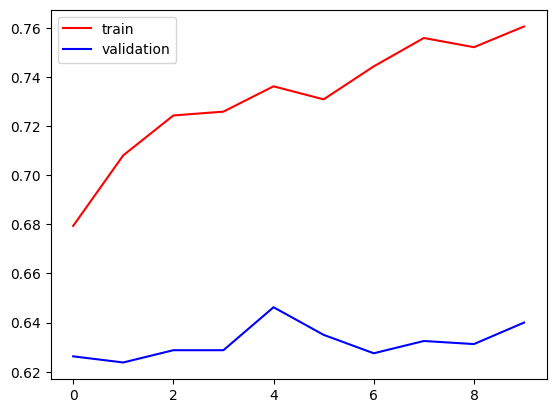

In [20]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

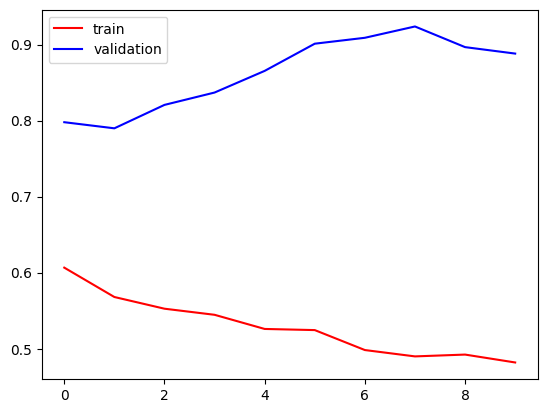

In [21]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()